<a href="https://colab.research.google.com/github/TinsuPhD/PhD-Phyton-Code-Repository/blob/main/Week_2_assignement.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Saving impact_analysis.csv to impact_analysis.csv
Dataset preview:
   gender economic_status  kindness  optimism
0    male         wealthy         4         4
1    male         wealthy         2         5
2    male         wealthy         2         3
3  female            poor         6         2
4    male          middle         2         5 

Data info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   gender           2000 non-null   object
 1   economic_status  2000 non-null   object
 2   kindness         2000 non-null   int64 
 3   optimism         2000 non-null   int64 
dtypes: int64(2), object(2)
memory usage: 62.6+ KB
None 



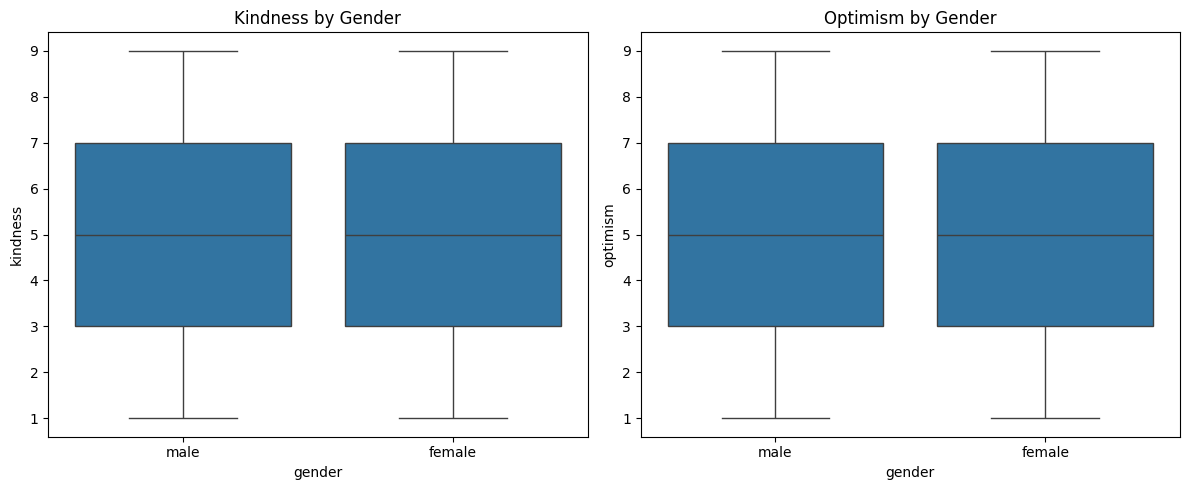

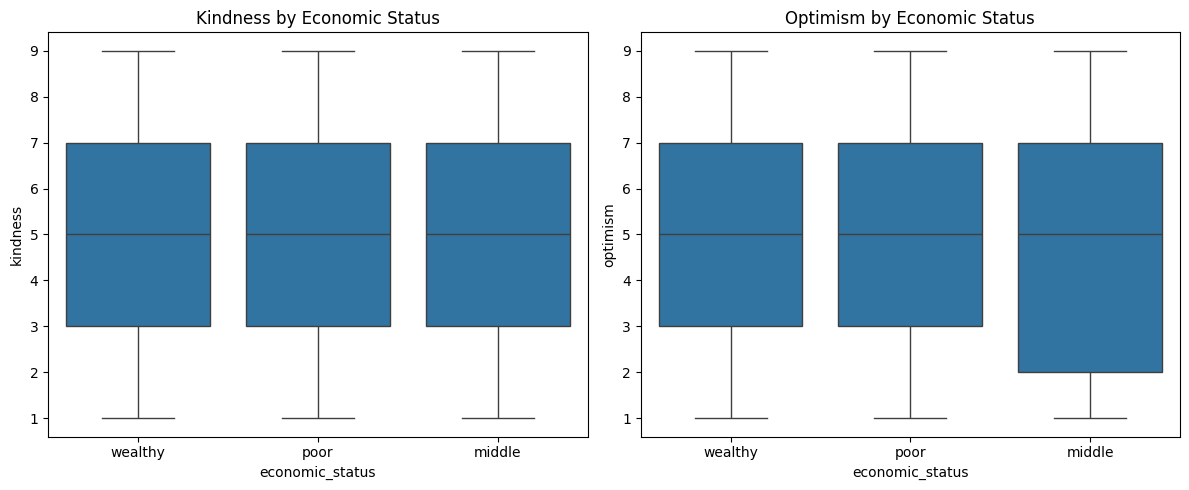

ANOVA: kindness ~ gender
                  sum_sq      df         F    PR(>F)
C(gender)      2.036547     1.0  0.307995  0.578975
Residual   13211.315453  1998.0       NaN       NaN 

ANOVA: optimism ~ gender
                  sum_sq      df         F    PR(>F)
C(gender)      7.212786     1.0  1.079182  0.299006
Residual   13353.766714  1998.0       NaN       NaN 

ANOVA: kindness ~ economic_status
                           sum_sq      df         F    PR(>F)
C(economic_status)      5.411058     2.0  0.409068  0.664325
Residual            13207.940942  1997.0       NaN       NaN 

ANOVA: optimism ~ economic_status
                           sum_sq      df         F    PR(>F)
C(economic_status)      8.150214     2.0  0.609458  0.543747
Residual            13352.829286  1997.0       NaN       NaN 

MANOVA: kindness + optimism ~ gender
                   Multivariate linear model
                                                                
---------------------------------------------

In [2]:
#  Import libraries
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from statsmodels.formula.api import ols
import statsmodels.api as sm
from statsmodels.multivariate.manova import MANOVA
from google.colab import files
import io

# Upload dataset into Colab session
#    Supports both CSV and Excel formats
uploaded = files.upload()

# Load the uploaded file into a DataFrame
filename = list(uploaded.keys())[0]
if filename.lower().endswith(('.xlsx', '.xls')):
    df = pd.read_excel(io.BytesIO(uploaded[filename]), sheet_name=0)
elif filename.lower().endswith('.csv'):
    df = pd.read_csv(io.BytesIO(uploaded[filename]))
else:
    raise ValueError("Unsupported file format. Please upload a .csv or .xlsx file.")

# Preview the data
print("Dataset preview:")
print(df.head(), "\n")
print("Data info:")
print(df.info(), "\n")


# Exploratory plots
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
sns.boxplot(x='gender', y='kindness', data=df)
plt.title('Kindness by Gender')

plt.subplot(1,2,2)
sns.boxplot(x='gender', y='optimism', data=df)
plt.title('Optimism by Gender')

plt.tight_layout()
plt.show()

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
sns.boxplot(x='economic_status', y='kindness', data=df)
plt.title('Kindness by Economic Status')

plt.subplot(1,2,2)
sns.boxplot(x='economic_status', y='optimism', data=df)
plt.title('Optimism by Economic Status')

plt.tight_layout()
plt.show()

# One‐way ANOVA for each dependent variable
def run_anova(dep_var, factor):
    formula = f'{dep_var} ~ C({factor})'
    model = ols(formula, data=df).fit()
    table = sm.stats.anova_lm(model, typ=2)
    print(f"ANOVA: {dep_var} ~ {factor}\n", table, "\n")

# ANOVA by gender
run_anova('kindness', 'gender')
run_anova('optimism', 'gender')

# ANOVA by economic_status
run_anova('kindness', 'economic_status')
run_anova('optimism', 'economic_status')

# MANOVA: joint test of kindness & optimism
def run_manova(deps, factor):
    deps_str = ' + '.join(deps)
    formula = f'{deps_str} ~ C({factor})'
    m = MANOVA.from_formula(formula, data=df)
    print(f"MANOVA: {deps_str} ~ {factor}")
    print(m.mv_test(), "\n")

# MANOVA by gender
run_manova(['kindness','optimism'], 'gender')

# MANOVA by economic_status
run_manova(['kindness','optimism'], 'economic_status')
